In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, average_precision_score, precision_recall_curve
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.utils import plot_model
from matplotlib.patches import Patch

In [5]:
daily_questionnaire = pd.read_csv("/content/anonym_aamos00_dailyquestionnaire.csv")
environment = pd.read_csv("/content/anonym_aamos00_environment.csv").dropna()
smartwatch1 = pd.read_csv("/content/anonym_aamos00_smartwatch1.csv")
smartwatch1.dropna(inplace=True)
smartwatch2 = pd.read_csv("/content/anonym_aamos00_smartwatch2.csv")
smartwatch2.dropna(inplace=True)
smartwatch3 = pd.read_csv("/content/anonym_aamos00_smartwatch3.csv")
smartwatch3.dropna(inplace=True)

In [6]:
smartwatch_all = pd.concat([smartwatch1, smartwatch2, smartwatch3], ignore_index=True)
smartwatch_all = smartwatch_all[smartwatch_all['hr'] >= 40]

smartwatch_daily = (
    smartwatch_all.groupby(["user_key", "date"], as_index=False)
    .agg(
        heart_rate=("hr", "mean"),
        # hr_min=("hr", "min"),
        # hr_max=("hr", "max"),
        # hr_std=("hr", "std"),
    )
)

# In rare single-reading days, std can be NaN; use 0.0 for stability.
# smartwatch_daily["hr_std"] = smartwatch_daily["hr_std"].fillna(0.0)

In [7]:
merged_env_hr = pd.merge(environment, smartwatch_daily, on=["user_key", "date"], how="left")

master_dataset = pd.merge(merged_env_hr, daily_questionnaire, on=["user_key", "date"], how="left")
master_dataset.drop(['temperature_min', 'temperature_max', 'wind_deg','daily_night_symp', 'daily_day_symp', 'daily_limit_activity', 'daily_prev_inhaler', 'daily_relief_inhaler', 'aqi'], axis=1, inplace=True)
master_dataset['daily_triggers'] = master_dataset['daily_triggers'].astype(str).apply(lambda x: 0 if '1' in x.split(',') else 1)

master_dataset.to_csv("master_dataset.csv", index=False)

print(f"Master dataset created and saved as 'master_dataset.csv'. Shape: {master_dataset.shape}")
master_dataset.head()

Master dataset created and saved as 'master_dataset.csv'. Shape: (1602, 19)


,user_key,date,temperature,pressure,humidity,wind_speed,co,no,no2,o3,so2,pm2_5,pm10,nh3,grass_pollen,tree_pollen,weed_pollen,heart_rate,daily_triggers
0,113,1,15.91,1015,88,0.89,161.89,0.19,8.65,47.92,2.89,7.55,8.51,0.82,High,Low,Moderate,83.867622,1
1,113,2,16.67,1014,96,0.45,178.58,0.55,15.94,28.97,6.68,3.97,4.82,0.29,High,Moderate,High,85.965126,1
2,113,3,17.07,1015,79,1.34,153.54,0.49,8.14,56.51,3.04,3.93,7.39,0.65,High,Moderate,High,89.994488,1
3,113,4,18.08,1017,78,0.89,156.88,0.19,2.29,79.39,0.78,2.91,4.09,1.20,High,Moderate,Moderate,84.652535,1
4,113,5,20.82,1015,86,1.79,163.56,0.11,4.84,78.68,1.85,8.35,9.05,1.63,High,Low,Moderate,79.638037,1


In [8]:
master_dataset.dropna(inplace=True)
master_dataset.shape

(1205, 19)

In [9]:
master_dataset.isna().sum()

,0
user_key,0
date,0
temperature,0
pressure,0
humidity,0
wind_speed,0
co,0
no,0
no2,0
o3,0


In [10]:
master_dataset

,user_key,date,temperature,pressure,humidity,wind_speed,co,no,no2,o3,so2,pm2_5,pm10,nh3,grass_pollen,tree_pollen,weed_pollen,heart_rate,daily_triggers
0,113,1,15.91,1015,88,0.89,161.89,0.19,8.65,47.92,2.89,7.55,8.51,0.82,High,Low,Moderate,83.867622,1
1,113,2,16.67,1014,96,0.45,178.58,0.55,15.94,28.97,6.68,3.97,4.82,0.29,High,Moderate,High,85.965126,1
2,113,3,17.07,1015,79,1.34,153.54,0.49,8.14,56.51,3.04,3.93,7.39,0.65,High,Moderate,High,89.994488,1
3,113,4,18.08,1017,78,0.89,156.88,0.19,2.29,79.39,0.78,2.91,4.09,1.20,High,Moderate,Moderate,84.652535,1
4,113,5,20.82,1015,86,1.79,163.56,0.11,4.84,78.68,1.85,8.35,9.05,1.63,High,Low,Moderate,79.638037,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,939,174,10.52,1005,86,0.89,173.57,0.92,12.00,11.44,1.49,3.62,4.90,1.77,Low,Low,Low,74.695545,1
1594,939,175,9.49,1004,90,2.06,196.93,0.00,2.55,50.78,1.00,1.29,1.54,0.97,Low,Moderate,Low,66.709226,0
1595,939,176,11.08,1014,86,0.45,198.60,0.07,4.80,57.22,1.94,1.77,3.76,0.86,Moderate,Moderate,Low,82.671031,0
1596,939,177,10.98,1022,91,2.06,193.60,0.01,2.64,45.78,0.97,5.29,10.34,1.01,Moderate,Moderate,Low,70.260626,1


In [11]:
master_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1205 entries, 0 to 1597
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_key        1205 non-null   int64  
 1   date            1205 non-null   int64  
 2   temperature     1205 non-null   float64
 3   pressure        1205 non-null   int64  
 4   humidity        1205 non-null   int64  
 5   wind_speed      1205 non-null   float64
 6   co              1205 non-null   float64
 7   no              1205 non-null   float64
 8   no2             1205 non-null   float64
 9   o3              1205 non-null   float64
 10  so2             1205 non-null   float64
 11  pm2_5           1205 non-null   float64
 12  pm10            1205 non-null   float64
 13  nh3             1205 non-null   float64
 14  grass_pollen    1205 non-null   object 
 15  tree_pollen     1205 non-null   object 
 16  weed_pollen     1205 non-null   object 
 17  heart_rate      1205 non-null   float6

In [12]:
master_dataset['daily_triggers'].value_counts()

,count
daily_triggers,
1,965
0,240


In [13]:
ohe = OneHotEncoder(sparse_output=False)
cols = ['grass_pollen', 'tree_pollen', 'weed_pollen']

# for col in cols:
encoded = ohe.fit_transform(master_dataset[cols])
print(ohe.get_feature_names_out(cols), encoded.shape)

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols))

master_dataset = master_dataset.drop(columns=cols).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

master_dataset = pd.concat([master_dataset, encoded_df], axis=1)

master_dataset.shape, master_dataset.columns

['grass_pollen_High' 'grass_pollen_Low' 'grass_pollen_Moderate'
 'tree_pollen_High' 'tree_pollen_Low' 'tree_pollen_Moderate'
 'weed_pollen_High' 'weed_pollen_Low' 'weed_pollen_Moderate'
 'weed_pollen_Very High'] (1205, 10)


((1205, 26),
 Index(['user_key', 'date', 'temperature', 'pressure', 'humidity', 'wind_speed',
        'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'heart_rate',
        'daily_triggers', 'grass_pollen_High', 'grass_pollen_Low',
        'grass_pollen_Moderate', 'tree_pollen_High', 'tree_pollen_Low',
        'tree_pollen_Moderate', 'weed_pollen_High', 'weed_pollen_Low',
        'weed_pollen_Moderate', 'weed_pollen_Very High'],
       dtype='object'))

In [14]:
master_dataset['daily_triggers'].value_counts()

,count
daily_triggers,
1,965
0,240


In [15]:
master_dataset.max()

,0
user_key,939.00
date,183.00
temperature,36.78
pressure,1042.00
humidity,100.00
wind_speed,14.86
co,500.68
no,132.32
no2,68.55
o3,161.65


In [16]:
master_dataset.min()

,0
user_key,113.000000
date,0.000000
temperature,-2.740000
pressure,982.000000
humidity,29.000000
wind_speed,0.000000
co,125.170000
no,0.000000
no2,0.120000
o3,0.000000


In [17]:
# std_cols = ["temperature", "pressure", "humidity", "wind_speed", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3", "grass_pollen", "tree_pollen",
# "weed_pollen"]
std_cols = ['user_key',"temperature", "pressure", "humidity", "wind_speed", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3", "heart_rate"]#, 'hr_min', 'hr_max', 'hr_std']

# sns.pairplot(master_dataset[std_cols])

In [18]:
print(master_dataset['user_key'].unique())
# lbl = LabelEncoder()
# master_dataset['user_key'] = lbl.fit_transform(master_dataset['user_key'])
master_dataset

[113 190 217 278 294 328 343 398 447 454 473 514 625 701 702 748 764 808
 917 939]


,user_key,date,temperature,pressure,humidity,wind_speed,co,no,no2,o3,...,grass_pollen_High,grass_pollen_Low,grass_pollen_Moderate,tree_pollen_High,tree_pollen_Low,tree_pollen_Moderate,weed_pollen_High,weed_pollen_Low,weed_pollen_Moderate,weed_pollen_Very High
0,113,1,15.91,1015,88,0.89,161.89,0.19,8.65,47.92,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,113,2,16.67,1014,96,0.45,178.58,0.55,15.94,28.97,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,113,3,17.07,1015,79,1.34,153.54,0.49,8.14,56.51,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,113,4,18.08,1017,78,0.89,156.88,0.19,2.29,79.39,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,113,5,20.82,1015,86,1.79,163.56,0.11,4.84,78.68,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,939,174,10.52,1005,86,0.89,173.57,0.92,12.00,11.44,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1201,939,175,9.49,1004,90,2.06,196.93,0.00,2.55,50.78,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1202,939,176,11.08,1014,86,0.45,198.60,0.07,4.80,57.22,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1203,939,177,10.98,1022,91,2.06,193.60,0.01,2.64,45.78,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [19]:
std = StandardScaler()
mn = MinMaxScaler()
# master_dataset_scaled = master_dataset.copy()
master_dataset[std_cols] = std.fit_transform(master_dataset[std_cols])
master_dataset.rename(columns={'weed_pollen_Very High': 'weed_pollen_Very_High'}, inplace=True)
# master_dataset[std_cols] = mn.fit_transform(master_dataset[std_cols])
master_dataset

,user_key,date,temperature,pressure,humidity,wind_speed,co,no,no2,o3,...,grass_pollen_High,grass_pollen_Low,grass_pollen_Moderate,tree_pollen_High,tree_pollen_Low,tree_pollen_Moderate,weed_pollen_High,weed_pollen_Low,weed_pollen_Moderate,weed_pollen_Very_High
0,-1.340623,1,0.523263,-0.010119,0.355649,-0.918485,-1.494088,-0.130733,0.052463,-0.150994,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.340623,2,0.647253,-0.104640,1.037657,-1.085795,-1.158812,-0.078578,0.900726,-0.970503,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-1.340623,3,0.712511,-0.010119,-0.411610,-0.747373,-1.661827,-0.087271,-0.006880,0.220488,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,-1.340623,4,0.877287,0.178923,-0.496861,-0.918485,-1.594731,-0.130733,-0.687585,1.209953,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.340623,5,1.324304,-0.010119,0.185147,-0.576260,-1.460540,-0.142323,-0.390867,1.179248,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,1.848092,174,-0.356088,-0.955327,0.185147,-0.918485,-1.259455,-0.024975,0.442268,-1.728602,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1201,1.848092,175,-0.524127,-1.049848,0.526151,-0.473593,-0.790189,-0.158259,-0.657331,-0.027311,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1202,1.848092,176,-0.264727,-0.104640,0.185147,-1.085795,-0.756641,-0.148118,-0.395522,0.251192,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1203,1.848092,177,-0.281041,0.651527,0.611402,-0.473593,-0.857083,-0.156811,-0.646859,-0.243540,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [20]:
feature_cols = [col for col in master_dataset.columns if col not in ['date', 'daily_triggers', 'wind_speed', 'humidity']]#, 'grass_pollen', 'tree_pollen', 'weed_pollen']]
# feature_cols = [col for col in master_dataset.columns if col not in ['user_key', 'date', 'daily_triggers', 'wind_speed', 'humidity', 'temperature', 'pressure']]
X = master_dataset[feature_cols]
y = master_dataset['daily_triggers']

print(f"Dataset shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Class distribution:\n{y.value_counts()}")

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=11)
# print(f"\nTraining: {X_train.shape}, Testing: {X_test.shape}")

# split_idx = int(0.7 * len(X))

# X_train = X[:split_idx]
# X_test  = X[split_idx:]

# y_train = y[:split_idx]
# y_test  = y[split_idx:]

# print(f"Training: {X_train.shape}, Testing: {X_test.shape}")

Dataset shape: (1205, 22)
Features: 22
Class distribution:
daily_triggers
1    965
0    240
Name: count, dtype: int64


In [21]:
user_std = {
    "User 1":  -1.340623,
    "User 2":  -0.641886,
    "User 3":  -1.043370,
    "User 4":  -0.452724,
    "User 5":   0.933170,
    "User 6":   1.848092,
    "User 7":   0.929310,
    "User 8":  -0.051240,
    "User 9":   0.207409,
    "User 10":  0.049132,
    "User 11":  1.342376,
    "User 12":  0.635917,
    "User 13":  1.763163,
    "User 14": -0.240401,
    "User 15":  1.172517,
    "User 16": -0.510631,
    "User 17": -0.024217,
    "User 18": -0.939139,
    "User 19": -0.703652,
    "User 20":  1.110750
}

In [22]:
test_users = [
    "User 2",
    "User 4",
    "User 12",
    "User 14",
    "User 15",
    "User 17"
]

test_values = np.array([user_std[u] for u in test_users])

test_mask = np.isclose(
    X["user_key"].to_numpy()[:, None],
    test_values[None, :],
    rtol=0,
    atol=1e-6
).any(axis=1)

temp_cols = feature_cols.copy()
temp_cols.append('daily_triggers')

test_df = master_dataset[temp_cols][test_mask].copy()
train_df = master_dataset[temp_cols][~test_mask].copy()

In [23]:
print("Train patients:", train_df["user_key"].nunique())
print("Test patients:", test_df["user_key"].nunique())

print("\nTrain:")
print(train_df["daily_triggers"].value_counts())

print("\nTest:")
print(test_df["daily_triggers"].value_counts())

# Verify no patient overlap
train_values = train_df["user_key"].unique()
test_values_actual = test_df["user_key"].unique()

overlap = [
    x for x in test_values_actual
    if np.isclose(x, train_values, rtol=0, atol=1e-6).any()
]

print("\nPatient overlap:", overlap)

Train patients: 14
Test patients: 6

Train:
daily_triggers
1    675
0    168
Name: count, dtype: int64

Test:
daily_triggers
1    290
0     72
Name: count, dtype: int64

Patient overlap: []


In [24]:
target = "daily_triggers"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [25]:
X_train.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [26]:
X_test.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [27]:
y_test.value_counts(), y_train.value_counts()

(daily_triggers
 1    290
 0     72
 Name: count, dtype: int64,
 daily_triggers
 1    675
 0    168
 Name: count, dtype: int64)

In [28]:
# std_train = StandardScaler().set_output(transform="pandas")
# std_test = StandardScaler().set_output(transform="pandas")

# X_train = std_train.fit_transform(X_train)
# X_test = std_test.fit_transform(X_train)

X_train

,user_key,temperature,pressure,co,no,no2,o3,so2,pm2_5,pm10,...,grass_pollen_High,grass_pollen_Low,grass_pollen_Moderate,tree_pollen_High,tree_pollen_Low,tree_pollen_Moderate,weed_pollen_High,weed_pollen_Low,weed_pollen_Moderate,weed_pollen_Very_High
0,-1.340623,0.523263,-0.010119,-1.494088,-0.130733,0.052463,-0.150994,0.265605,0.417497,0.268178,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.340623,0.647253,-0.104640,-1.158812,-0.078578,0.900726,-0.970503,1.807533,-0.182029,-0.288280,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-1.340623,0.712511,-0.010119,-1.661827,-0.087271,-0.006880,0.220488,0.326631,-0.188727,0.099280,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,-1.340623,0.877287,0.178923,-1.594731,-0.130733,-0.687585,1.209953,-0.592830,-0.359542,-0.398365,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.340623,1.324304,-0.010119,-1.460540,-0.142323,-0.390867,1.179248,-0.157510,0.551470,0.349611,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,1.848092,-0.356088,-0.955327,-1.259455,-0.024975,0.442268,-1.728602,-0.303973,-0.240641,-0.276216,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1201,1.848092,-0.524127,-1.049848,-0.790189,-0.158259,-0.657331,-0.027311,-0.503325,-0.630836,-0.782909,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1202,1.848092,-0.264727,-0.104640,-0.756641,-0.148118,-0.395522,0.251192,-0.120894,-0.550452,-0.448130,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1203,1.848092,-0.281041,0.651527,-0.857083,-0.156811,-0.646859,-0.243540,-0.515530,0.039026,0.544145,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [29]:
X_test

,user_key,temperature,pressure,co,no,no2,o3,so2,pm2_5,pm10,...,grass_pollen_High,grass_pollen_Low,grass_pollen_Moderate,tree_pollen_High,tree_pollen_Low,tree_pollen_Moderate,weed_pollen_High,weed_pollen_Low,weed_pollen_Moderate,weed_pollen_Very_High
290,-0.641886,1.077956,0.557006,-1.561184,-0.130733,-0.829544,0.622242,-0.788114,-0.401408,-0.559723,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
291,-0.641886,0.325858,0.273444,-1.628279,-0.075681,-0.186074,-0.924230,-0.572488,-0.321025,-0.433050,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
292,-0.641886,0.371538,0.273444,-1.460540,0.074988,1.179989,-1.016776,1.709891,0.039026,0.082692,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
293,-0.641886,0.126821,0.367964,-2.131093,-0.098861,-0.017353,-0.970503,-0.710814,1.201235,1.120207,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
294,-0.641886,0.396010,0.178923,-1.963555,-0.136528,-0.305925,-0.784978,-0.841003,-0.068152,-0.181211,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,1.172517,-0.132579,-0.199160,-0.454913,-0.158259,-0.933104,-0.259109,-0.653856,-0.645907,-0.424001,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1047,1.172517,0.356855,-0.766285,-0.052541,-0.148118,-0.890051,0.065668,-0.556214,-0.429877,-0.610995,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1048,1.172517,0.195342,-0.482723,-0.320722,-0.153913,-0.940085,0.127509,-0.552146,-0.116717,1.293628,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1049,1.172517,0.193710,-0.388202,0.685107,-0.151016,-0.873760,0.282329,-0.678267,-0.391360,-0.499402,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [30]:
X_train.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [31]:
X_test.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [32]:
master_dataset['user_key'].value_counts()

,count
user_key,
-0.641886,154
-1.340623,152
-1.043370,134
-0.452724,123
0.933170,112
1.848092,102
0.929310,94
-0.051240,90
0.049132,51


In [33]:
master_dataset[['user_key', 'daily_triggers']].value_counts()

,,count
user_key,daily_triggers,
-1.340623,1,152
-0.641886,1,152
-1.043370,1,134
-0.452724,1,112
0.933170,0,88
1.848092,1,79
0.929310,1,77
-0.051240,1,68
0.207409,1,43


In [34]:
print(X_train.user_key.unique())
print(X_test.user_key.unique())

[-1.34062346 -1.0433703  -0.93913867 -0.7036524  -0.51063086 -0.05123961
  0.04913159  0.20740925  0.92930979  0.93317022  1.11075003  1.34237588
  1.76316282  1.8480923 ]
[-0.64188551 -0.4527244  -0.24040071 -0.02421659  0.63591706  1.17251692]


In [35]:
print("Random Forest")
rf = RandomForestClassifier(n_estimators=120, random_state=151)

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
pres_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

auprc_rf = average_precision_score(y_test, y_pred_proba_rf)
auroc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Test Accuracy: {acc_rf:.4f}")
print(f"Test F1-Score: {f1_rf:.4f}")
print(f"Test Precision: {pres_rf:.4f}")
print(f"Test Recall: {rec_rf:.4f}")
print(f"Test AUPRC: {auprc_rf:.4f}")
print(f"Test AUROC: {auroc_rf:.4f}")

feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Important Features:")
print(feature_importance_rf.head(15))

Random Forest
CV Acc: 0.5702
Test Accuracy: 0.8011
Test F1-Score: 0.8896
Test Precision: 0.8011
Test Recall: 1.0000
Test AUPRC: 0.8783
Test AUROC: 0.6391

Top 15 Important Features:
                  feature  importance
0                user_key    0.178601
11             heart_rate    0.093914
7                     so2    0.083958
10                    nh3    0.080777
9                    pm10    0.071827
5                     no2    0.069698
3                      co    0.066125
1             temperature    0.064502
8                   pm2_5    0.063639
2                pressure    0.059499
6                      o3    0.056230
4                      no    0.041985
14  grass_pollen_Moderate    0.012780
20   weed_pollen_Moderate    0.008837
13       grass_pollen_Low    0.008434


In [36]:
print("XGBoost")
xgb_model = XGBClassifier(n_estimators=100, random_state=151, eval_metric='logloss')

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=8, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
pres_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)

auprc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"Test Accuracy: {acc_xgb:.4f}")
print(f"Test F1-Score: {f1_xgb:.4f}")
print(f"Test Precision Score: {pres_xgb:.4f}")
print(f"Test Recall Score: {rec_xgb:.4f}")
print(f"Test AUPRC: {auprc_xgb:.4f}")
print(f"Test AUROC: {auroc_xgb:.4f}")

feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Important Features:")
print(feature_importance_xgb.head(15))

XGBoost
CV Acc: 0.6888
Test Accuracy: 0.7486
Test F1-Score: 0.8549
Test Precision Score: 0.7953
Test Recall Score: 0.9241
Test AUPRC: 0.7675
Test AUROC: 0.4455

Top 15 Important Features:
                  feature  importance
0                user_key    0.289321
16        tree_pollen_Low    0.103743
21  weed_pollen_Very_High    0.067539
17   tree_pollen_Moderate    0.042467
11             heart_rate    0.042018
3                      co    0.039894
20   weed_pollen_Moderate    0.039499
10                    nh3    0.038644
2                pressure    0.037868
5                     no2    0.037470
1             temperature    0.037413
7                     so2    0.034698
9                    pm10    0.031240
14  grass_pollen_Moderate    0.030536
8                   pm2_5    0.029281


In [37]:
print("Logistic Regression")
lr = LogisticRegression(random_state=151, max_iter=150, C=0.5)

cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
pres_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)

auprc_lr = average_precision_score(y_test, y_pred_proba_lr)
auroc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Test Accuracy: {acc_lr:.4f}")
print(f"Test F1-Score: {f1_lr:.4f}")
print(f"Test Precision Score: {pres_lr:.4f}")
print(f"Test Recall Score: {rec_lr:.4f}")
print(f"Test AUPRC: {auprc_lr:.4f}")
print(f"Test AUROC: {auroc_lr:.4f}")

feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': abs(lr.coef_[0])
}).sort_values('coefficient', ascending=False)

print(f"\nTop 10 Important Features (weight):")
print(feature_importance_lr.head(10))

Logistic Regression
CV Acc: 0.6626
Test Accuracy: 0.8094
Test F1-Score: 0.8937
Test Precision Score: 0.8078
Test Recall Score: 1.0000
Test AUPRC: 0.8295
Test AUROC: 0.6231

Top 10 Important Features (weight):
                  feature  coefficient
0                user_key     0.744863
7                     so2     0.581531
14  grass_pollen_Moderate     0.581173
9                    pm10     0.573954
8                   pm2_5     0.529007
17   tree_pollen_Moderate     0.418117
16        tree_pollen_Low     0.336565
13       grass_pollen_Low     0.325475
2                pressure     0.304556
12      grass_pollen_High     0.257638


In [38]:
print("Gradient Boosting")
gb = GradientBoostingClassifier(n_estimators=50, random_state=151, learning_rate=1.2)

cv_scores = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
pres_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)

auprc_gb = average_precision_score(y_test, y_pred_proba_gb)
auroc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print(f"Test Accuracy: {acc_gb:.4f}")
print(f"Test F1-Score: {f1_gb:.4f}")
print(f"Test Precision: {pres_gb:.4f}")
print(f"Test Recall: {rec_gb:.4f}")
print(f"Test AUPRC: {auprc_gb:.4f}")
print(f"Test AUROC: {auroc_gb:.4f}")

feature_importance_gb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(feature_importance_gb.head(10))

Gradient Boosting
CV Acc: 0.4954
Test Accuracy: 0.7624
Test F1-Score: 0.8608
Test Precision: 0.8110
Test Recall: 0.9172
Test AUPRC: 0.8460
Test AUROC: 0.6139

Top 10 Important Features:
        feature  importance
0      user_key    0.463650
3            co    0.100616
11   heart_rate    0.082307
9          pm10    0.060055
1   temperature    0.045255
5           no2    0.041636
10          nh3    0.033519
6            o3    0.030968
8         pm2_5    0.029946
2      pressure    0.029701


In [39]:
print("Neural Network (MLP)")
mlp = MLPClassifier(hidden_layer_sizes=(22,16), random_state=151, max_iter=150)

cv_scores = cross_val_score(mlp, X_train, y_train, cv=3, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_pred_proba_mlp = mlp.predict_proba(X_test)[:, 1]

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)
pres_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)

auprc_mlp = average_precision_score(y_test, y_pred_proba_mlp)
auroc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)

print(f"Test Accuracy: {acc_mlp:.4f}")
print(f"Test F1-Score: {f1_mlp:.4f}")
print(f"Test Precision: {pres_mlp:.4f}")
print(f"Test Recall: {rec_mlp:.4f}")
print(f"Test AUPRC: {auprc_mlp:.4f}")
print(f"Test AUROC: {auroc_mlp:.4f}")

Neural Network (MLP)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


CV Acc: 0.5469
Test Accuracy: 0.8066
Test F1-Score: 0.8920
Test Precision: 0.8073
Test Recall: 0.9966
Test AUPRC: 0.8343
Test AUROC: 0.6378


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [40]:
print("Naive Bayes (Bernoulli)")
ber_nb = BernoulliNB()

cv_scores = cross_val_score(ber_nb, X_train, y_train, cv=3, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

ber_nb.fit(X_train, y_train)
y_pred_nb = ber_nb.predict(X_test)
y_pred_proba_nb = ber_nb.predict_proba(X_test)[:, 1]

acc_ber_nb = accuracy_score(y_test, y_pred_nb)
f1_ber_nb = f1_score(y_test, y_pred_nb)
pres_ber_nb = precision_score(y_test, y_pred_nb)
rec_ber_nb = recall_score(y_test, y_pred_nb)

auprc_ber_nb = average_precision_score(y_test, y_pred_proba_nb)
auroc_ber_nb = roc_auc_score(y_test, y_pred_proba_nb)

print(f"Test Accuracy: {acc_ber_nb:.4f}")
print(f"Test F1-Score: {f1_ber_nb:.4f}")
print(f"Test Precision: {pres_ber_nb:.4f}")
print(f"Test Recall: {rec_ber_nb:.4f}")
print(f"Test AUPRC: {auprc_ber_nb:.4f}")
print(f"Test AUROC: {auroc_ber_nb:.4f}")

print("\n\nNaive Bayes (Gaussian)")
gau_nb = GaussianNB()

cv_scores = cross_val_score(gau_nb, X_train, y_train, cv=20, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

gau_nb.fit(X_train, y_train)
y_pred_nb = gau_nb.predict(X_test)
y_pred_proba_nb = gau_nb.predict_proba(X_test)[:, 1]

acc_gau_nb = accuracy_score(y_test, y_pred_nb)
f1_gau_nb = f1_score(y_test, y_pred_nb)
pres_gau_nb = precision_score(y_test, y_pred_nb)
rec_gau_nb = recall_score(y_test, y_pred_nb)

auprc_gau_nb = average_precision_score(y_test, y_pred_proba_nb)
auroc_gau_nb = roc_auc_score(y_test, y_pred_proba_nb)

print(f"Test Accuracy: {acc_gau_nb:.4f}")
print(f"Test F1-Score: {f1_gau_nb:.4f}")
print(f"Test Precision: {pres_gau_nb:.4f}")
print(f"Test Recall: {rec_gau_nb:.4f}")
print(f"Test AUPRC: {auprc_gau_nb:.4f}")
print(f"Test AUROC: {auroc_gau_nb:.4f}")

Naive Bayes (Bernoulli)
CV Acc: 0.7082
Test Accuracy: 0.8232
Test F1-Score: 0.8974
Test Precision: 0.8383
Test Recall: 0.9655
Test AUPRC: 0.8950
Test AUROC: 0.7235


Naive Bayes (Gaussian)
CV Acc: 0.6437
Test Accuracy: 0.7652
Test F1-Score: 0.8506
Test Precision: 0.8674
Test Recall: 0.8345
Test AUPRC: 0.8733
Test AUROC: 0.7239


In [41]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree (Tuned)")
dt_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=12, min_samples_split=5, min_samples_leaf=5, random_state=151)

cv_scores = cross_val_score(dt_tuned, X_train, y_train, cv=3, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

dt_tuned.fit(X_train, y_train)
y_pred_dt = dt_tuned.predict(X_test)
y_pred_proba_dt = dt_tuned.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
pres_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)

auprc_gb = average_precision_score(y_test, y_pred_proba_dt)
auroc_gb = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Test Accuracy: {acc_dt:.4f}")
print(f"Test F1-Score: {f1_dt:.4f}")
print(f"Test Precision: {pres_dt:.4f}")
print(f"Test Recall: {rec_dt:.4f}")
print(f"Test AUPRC: {auprc_gb:.4f}")
print(f"Test AUROC: {auroc_gb:.4f}")

feature_importance_dt = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(feature_importance_dt.head(10))

Decision Tree (Tuned)
CV Acc: 0.4401
Test Accuracy: 0.6354
Test F1-Score: 0.7700
Test Precision: 0.7782
Test Recall: 0.7621
Test AUPRC: 0.7771
Test AUROC: 0.4352

Top 10 Important Features:
        feature  importance
0      user_key    0.489374
11   heart_rate    0.111794
10          nh3    0.099890
3            co    0.087468
5           no2    0.061464
1   temperature    0.060530
2      pressure    0.023750
6            o3    0.019893
7           so2    0.013430
8         pm2_5    0.012868


In [42]:
print("Bagging Classifier")
bag = BaggingClassifier(random_state=151, n_estimators=50)

cv_scores = cross_val_score(bag, X_train, y_train, cv=6, scoring='accuracy')
print(f"CV Acc: {cv_scores.mean():.4f}")

bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
# y_pred_proba_bag = bag.predict_proba(X_test)[:, 1]

acc_bag = accuracy_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)
pres_bag = precision_score(y_test, y_pred_bag)
rec_bag = recall_score(y_test, y_pred_bag)

auprc_bag = average_precision_score(y_test, y_pred_bag)
auroc_bag = roc_auc_score(y_test, y_pred_bag)

print(f"Test Accuracy: {acc_bag:.4f}")
print(f"Test F1-Score: {f1_bag:.4f}")
print(f"Test Precision: {pres_bag:.4f}")
print(f"Test Recall: {rec_bag:.4f}")
print(f"Test AUPRC: {auprc_bag:.4f}")
print(f"Test AUROC: {auroc_bag:.4f}")

feature_importance_bag = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.mean(
        [estimator.feature_importances_ for estimator in bag.estimators_],
        axis=0
    )
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance_bag.head(15))

Bagging Classifier
CV Acc: 0.6581
Test Accuracy: 0.7928
Test F1-Score: 0.8830
Test Precision: 0.8063
Test Recall: 0.9759
Test AUPRC: 0.8061
Test AUROC: 0.5157

Top 15 Important Features:
                  feature  importance
0                user_key    0.365091
3                      co    0.086921
11             heart_rate    0.076073
1             temperature    0.058568
2                pressure    0.058486
9                    pm10    0.057904
10                    nh3    0.057524
5                     no2    0.046055
8                   pm2_5    0.045327
7                     so2    0.045148
4                      no    0.033694
6                      o3    0.029218
14  grass_pollen_Moderate    0.007468
16        tree_pollen_Low    0.006759
20   weed_pollen_Moderate    0.006002


In [43]:
results_data = {
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression', 'Gradient Boosting', 'Neural Network', "Bernoulli NB", "Gaussian NB", "Bagging"],
    'F1-Score': [f1_rf, f1_xgb, f1_lr, f1_gb, f1_mlp, f1_ber_nb, f1_gau_nb, f1_bag],
    'Precision': [pres_rf, pres_xgb, pres_lr, pres_gb, pres_mlp, pres_ber_nb, pres_gau_nb, pres_bag],
    'Recall': [rec_rf, rec_xgb, rec_lr, rec_gb, rec_mlp, rec_ber_nb, rec_gau_nb, rec_bag],
    # 'AUROC': [auroc_rf, auroc_xgb, auroc_lr, auroc_gb, auroc_mlp, auroc_ber_nb, auroc_gau_nb, auroc_bag],
    'AUPRC': [auprc_rf, auprc_xgb, auprc_lr, auprc_gb, auprc_mlp, auprc_ber_nb, auprc_gau_nb, auprc_bag],
}

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(['F1-Score', 'AUPRC'], ascending=False)
print(results_df)

                 Model  F1-Score  Precision    Recall     AUPRC
5         Bernoulli NB  0.897436   0.838323  0.965517  0.894953
2  Logistic Regression  0.893683   0.807799  1.000000  0.829488
4       Neural Network  0.891975   0.807263  0.996552  0.834305
0        Random Forest  0.889571   0.801105  1.000000  0.878274
7              Bagging  0.882995   0.806268  0.975862  0.806143
3    Gradient Boosting  0.860841   0.810976  0.917241  0.777099
1              XGBoost  0.854864   0.795252  0.924138  0.767484
6          Gaussian NB  0.850615   0.867384  0.834483  0.873258


In [44]:
print("Test")
print(X_test['user_key'].value_counts())

Test
user_key
-0.641886    154
-0.452724    123
 0.635917     33
-0.240401     25
 1.172517     20
-0.024217      7
Name: count, dtype: int64


In [45]:
# print("Train")
# print(X_train['user_key'].value_counts())

In [46]:
import joblib
joblib.dump(bag, "bagging_model_unseen.joblib")
bagging_model = joblib.load("bagging_model_unseen.joblib")

<h2>Feedback loop</h2>

In [47]:
user_std = {
    "User 1":  -1.340623,
    "User 2":  -0.641886,
    "User 3":  -1.043370,
    "User 4":  -0.452724,
    "User 5":   0.933170,
    "User 6":   1.848092,
    "User 7":   0.929310,
    "User 8":  -0.051240,
    "User 9":   0.207409,
    "User 10":  0.049132,
    "User 11":  1.342376,
    "User 12":  0.635917,
    "User 13":  1.763163,
    "User 14": -0.240401,
    "User 15":  1.172517,
    "User 16": -0.510631,
    "User 17": -0.024217,
    "User 18": -0.939139,
    "User 19": -0.703652,
    "User 20":  1.110750
}

test_users = [
    "User 2",
    "User 4",
    "User 12",
    "User 14",
    "User 15",
    "User 17"
]

In [51]:
user_id = user_std['User 14']

# np.isclose returns a boolean mask directly
mask = np.isclose(X_test['user_key'], user_id)

user_X = X_test[mask].copy()
user_y = y_test[mask]

shuffled = user_X.sample(frac=1, random_state=67)
user_X = shuffled
user_y = user_y.loc[shuffled.index]

print('Number of records:', len(user_X))
print(user_X['user_key'].unique())
print(user_y.shape)
print(user_y.value_counts())

# Save the bagging model as 'bagging_model_population.joblib' as it's being loaded later.
import joblib
joblib.dump(bag, "bagging_model_population.joblib")
joblib.dump(bag, "bagging_model_patient_wise_general.joblib")

pop_model = joblib.load("bagging_model_population.joblib")
unseen_model = joblib.load("bagging_model_unseen.joblib")
gen_model = joblib.load("bagging_model_patient_wise_general.joblib")

gen_pred = gen_model.predict(user_X)
gen_prob = gen_model.predict_proba(user_X)[:, 1]

unseen_pred = unseen_model.predict(user_X)
unseen_prob = unseen_model.predict_proba(user_X)[:, 1]

print("Gen Predictions:")
print(gen_pred)
print("Unseen Predictions:")
print(unseen_pred)
print("\nGround truth:")
print(user_y.values)

Number of records: 25
[-0.24040071]
(25,)
daily_triggers
0    20
1     5
Name: count, dtype: int64
Gen Predictions:
[1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]
Unseen Predictions:
[1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]

Ground truth:
[0 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [52]:
user_X.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score

y_true = user_y.values

print("========================== General ========================== ")
print("Accuracy :", accuracy_score(y_true, gen_pred))
print("Precision:", precision_score(y_true, gen_pred, zero_division=0))
print("Recall   :", recall_score(y_true, gen_pred, zero_division=0))
print("F1       :", f1_score(y_true, gen_pred, zero_division=0))

if gen_prob is not None and len(np.unique(y_true)) == 2:
    print("AUPRC    :", average_precision_score(y_true, gen_prob))

print("========================== Unseen ========================== ")
print("Accuracy :", accuracy_score(y_true, unseen_pred))
print("Precision:", precision_score(y_true, unseen_pred, zero_division=0))
print("Recall   :", recall_score(y_true, unseen_pred, zero_division=0))
print("F1       :", f1_score(y_true, unseen_pred, zero_division=0))

if unseen_prob is not None and len(np.unique(y_true)) == 2:
    print("AUPRC    :", average_precision_score(y_true, unseen_prob))

========================== General ========================== 
Accuracy : 0.24
Precision: 0.18181818181818182
Recall   : 0.8
F1       : 0.2962962962962963
AUPRC    : 0.1517254675149412
========================== Unseen ========================== 
Accuracy : 0.24
Precision: 0.18181818181818182
Recall   : 0.8
F1       : 0.2962962962962963
AUPRC    : 0.1517254675149412


In [54]:
USER_WEIGHT = 4

feedback_X = []
feedback_y = []

predictions = []
probabilities = []
ground_truth = []

results = []

personalized_model = joblib.load('bagging_model_unseen.joblib')

for i, index in enumerate(user_X.index):

    x_current = user_X.loc[[index]]
    y_current = user_y.loc[index]

    prediction = personalized_model.predict(x_current)[0]

    if hasattr(personalized_model, "predict_proba"):
        probability = personalized_model.predict_proba(x_current)[0, 1]
    else:
        probability = np.nan

    actual = y_current

    predictions.append(prediction)
    probabilities.append(probability)
    ground_truth.append(actual)

    feedback_X.append(x_current)
    feedback_y.append(
        pd.Series([actual], index=[index], name=y_train.name)
    )

    y_so_far = np.array(ground_truth)
    pred_so_far = np.array(predictions)

    accuracy = accuracy_score(
        y_so_far,
        pred_so_far
    )

    precision = precision_score(
        y_so_far,
        pred_so_far,
        zero_division=0
    )

    recall = recall_score(
        y_so_far,
        pred_so_far,
        zero_division=0
    )

    f1 = f1_score(
        y_so_far,
        pred_so_far,
        zero_division=0
    )

    if len(np.unique(y_so_far)) == 2:
        auprc = average_precision_score(
            y_so_far,
            np.array(probabilities)
        )
    else:
        auprc = np.nan

    results.append({
        "record": i + 1,
        "index": index,
        "ground_truth": actual,
        "prediction": prediction,
        "probability": probability,
        "correct": int(prediction == actual),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auprc": auprc
    })

    if i < len(user_X) - 1:

        X_feedback = pd.concat(feedback_X, axis=0)
        y_feedback = pd.concat(feedback_y, axis=0)

        X_retrain = pd.concat(
            [X_train, X_feedback],
            axis=0
        )

        y_retrain = pd.concat(
            [y_train, y_feedback],
            axis=0
        )

        sample_weights = np.ones(len(X_retrain))
        sample_weights[len(X_train):] = USER_WEIGHT

        personalized_model = clone(bagging_model)

        personalized_model.fit(
            X_retrain,
            y_retrain,
            sample_weight=sample_weights
        )

results_df = pd.DataFrame(results)

In [55]:
final_result = results_df.iloc[-1]

print("Final personalized performance")
print("--------------------------------")
print("Accuracy :", final_result["accuracy"])
print("Precision:", final_result["precision"])
print("Recall   :", final_result["recall"])
print("F1       :", final_result["f1"])
print("AUPRC    :", final_result["auprc"])

Final personalized performance
--------------------------------
Accuracy : 0.48
Precision: 0.16666666666666666
Recall   : 0.4
F1       : 0.23529411764705882
AUPRC    : 0.20183792815371762


In [56]:
joblib.dump(personalized_model, 'bagging_model_PERSONALIZED_UNSEEN.joblib')

['bagging_model_PERSONALIZED_UNSEEN.joblib']

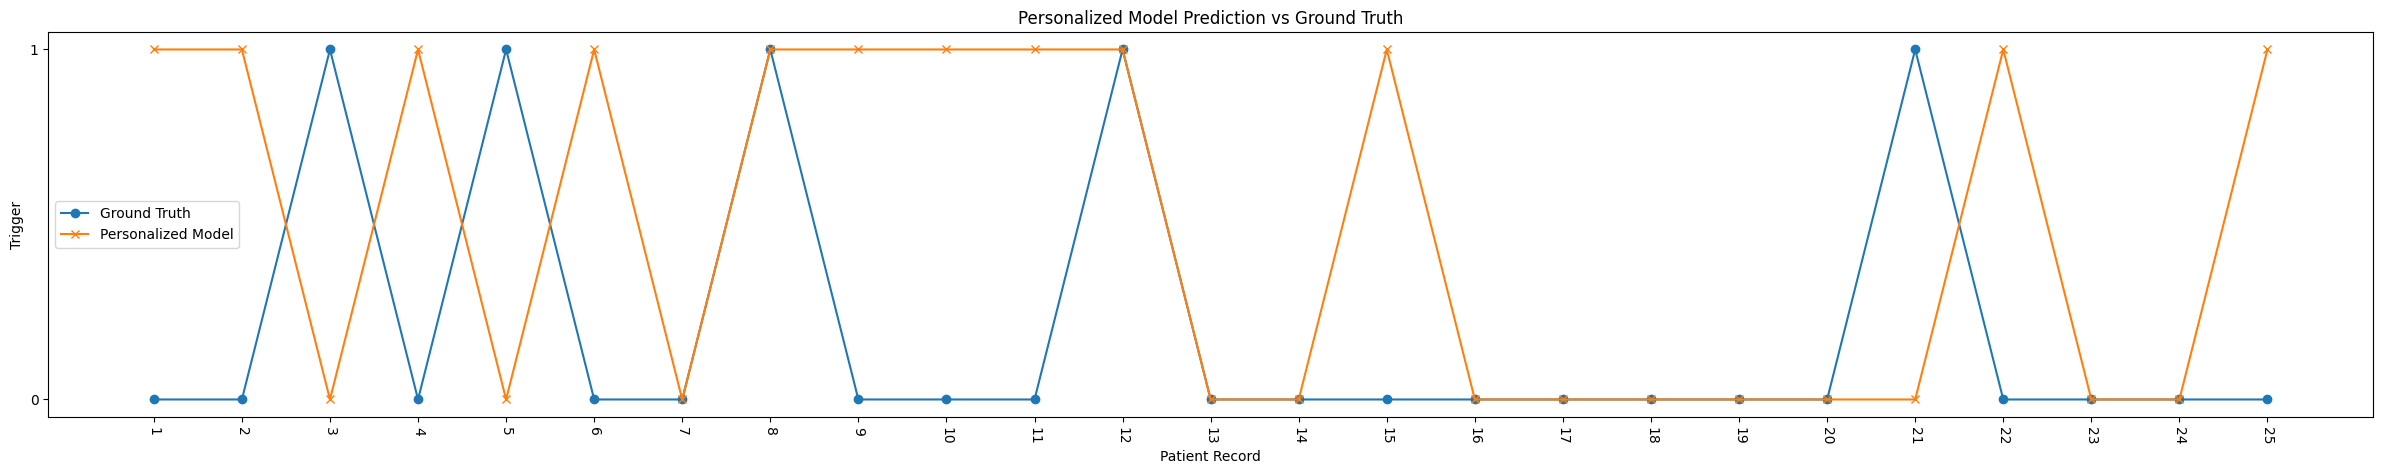

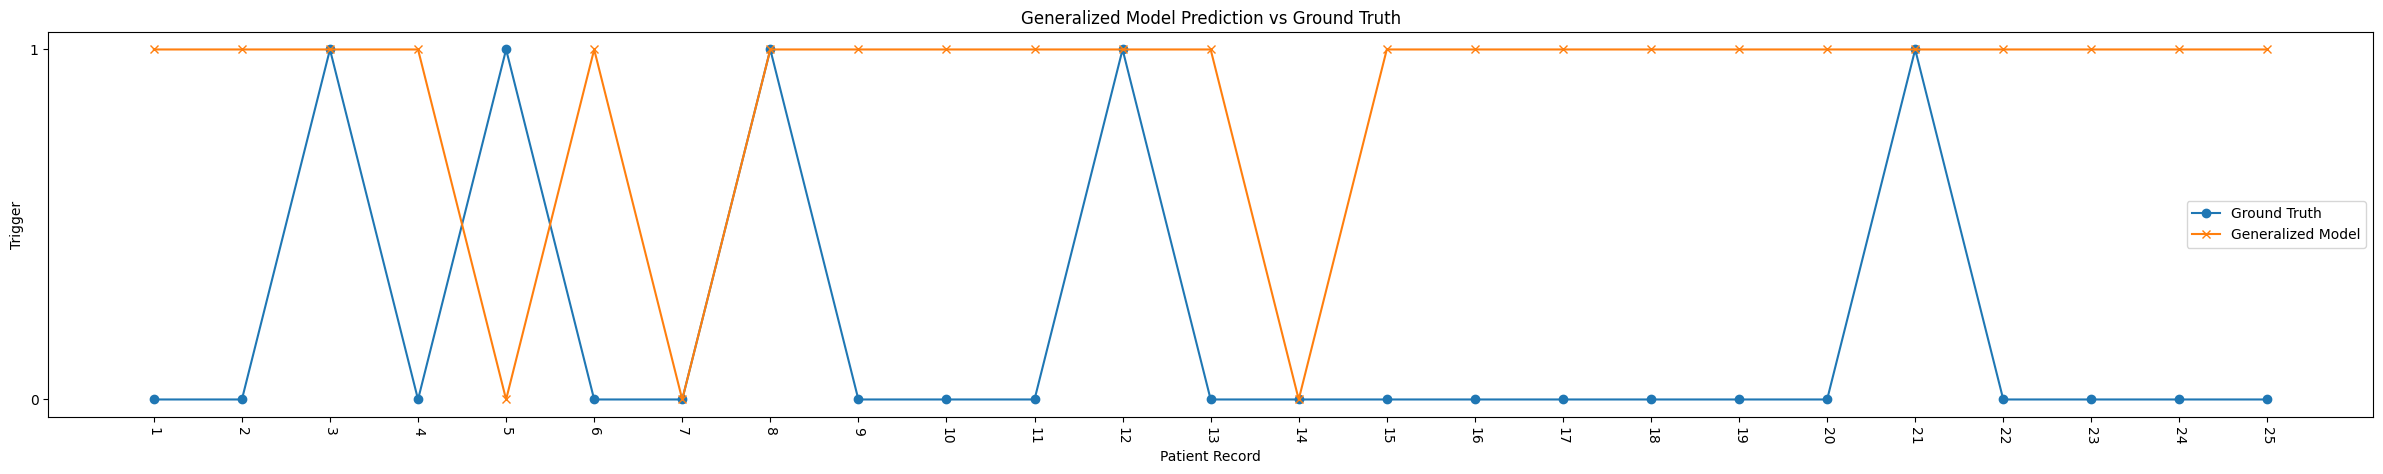

In [62]:
generalized_predictions = []
generalized_probabilities = []

for index in user_X.index:

    x_current = user_X.loc[[index]]

    prediction = joblib.load('bagging_model_unseen.joblib').predict(x_current)[0]
    pop_model = joblib.load('bagging_model_population.joblib').predict(x_current)[0]

    if hasattr(bagging_model, "predict_proba"):
        probability = bagging_model.predict_proba(x_current)[0, 1]
    else:
        probability = np.nan

    generalized_predictions.append(prediction)
    generalized_probabilities.append(probability)


records = range(1, len(user_X) + 1)

# ============================================
# 1. PERSONALIZED MODEL vs GROUND TRUTH
# ============================================

plt.figure(figsize=(30, 5))

plt.plot(
    records,
    user_y.values,
    marker="o",
    label="Ground Truth"
)

plt.plot(
    records,
    results_df["prediction"],
    marker="x",
    label="Personalized Model"
)

plt.xlabel("Patient Record")
plt.ylabel("Trigger")
plt.title("Personalized Model Prediction vs Ground Truth")

plt.yticks([0, 1])
plt.xticks(records, rotation=-90)

plt.legend()
plt.show()


# ============================================
# 2. GENERALIZED MODEL vs GROUND TRUTH
# ============================================

plt.figure(figsize=(30, 5))

plt.plot(
    records,
    user_y.values,
    marker="o",
    label="Ground Truth"
)

plt.plot(
    records,
    generalized_predictions,
    marker="x",
    label="Generalized Model"
)

plt.xlabel("Patient Record")
plt.ylabel("Trigger")
plt.title("Generalized Model Prediction vs Ground Truth")

plt.yticks([0, 1])
plt.xticks(records, rotation=-90)

plt.legend()
plt.show()

In [59]:
final_personalized = results_df.iloc[-1]

generalized_accuracy = accuracy_score(user_y, generalized_predictions)
generalized_precision = precision_score(user_y, generalized_predictions, zero_division=0)
generalized_recall = recall_score(user_y, generalized_predictions, zero_division=0)
generalized_f1 = f1_score(user_y, generalized_predictions, zero_division=0)
generalized_auprc = average_precision_score(user_y, generalized_probabilities)

print(f"{'Metric':<12} {'Generalized':>12} {'Personalized':>14}")
print("-" * 40)
print(f"{'Accuracy':<12} {generalized_accuracy:>12.4f} {final_personalized['accuracy']:>14.4f}")
print(f"{'Precision':<12} {generalized_precision:>12.4f} {final_personalized['precision']:>14.4f}")
print(f"{'Recall':<12} {generalized_recall:>12.4f} {final_personalized['recall']:>14.4f}")
print(f"{'F1':<12} {generalized_f1:>12.4f} {final_personalized['f1']:>14.4f}")
print(f"{'AUPRC':<12} {generalized_auprc:>12.4f} {final_personalized['auprc']:>14.4f}")

Metric        Generalized   Personalized
----------------------------------------
Accuracy           0.2400         0.4800
Precision          0.1818         0.1667
Recall             0.8000         0.4000
F1                 0.2963         0.2353
AUPRC              0.1517         0.2018


In [60]:
sequences = {
    "Original": user_X.index.tolist(),
    "Shuffle_1": user_X.sample(frac=1, random_state=113).index.tolist(),
    "Shuffle_2": user_X.sample(frac=1, random_state=87681).index.tolist(),
    "Shuffle_3": user_X.sample(frac=1, random_state=1384).index.tolist(),
    "Shuffle_4": user_X.sample(frac=1, random_state=18468468).index.tolist()
}

all_results = {}

for sequence_name, sequence in sequences.items():

    feedback_X = []
    feedback_y = []

    predictions = []
    probabilities = []
    ground_truth = []

    results = []

    personalized_model = bagging_model

    for i, index in enumerate(sequence):

        x_current = user_X.loc[[index]]
        y_current = user_y.loc[index]

        prediction = personalized_model.predict(x_current)[0]

        if hasattr(personalized_model, "predict_proba"):
            probability = personalized_model.predict_proba(x_current)[0, 1]
        else:
            probability = np.nan

        actual = y_current

        predictions.append(prediction)
        probabilities.append(probability)
        ground_truth.append(actual)

        feedback_X.append(x_current)
        feedback_y.append(
            pd.Series(
                [actual],
                index=[index],
                name=y_train.name
            )
        )

        y_so_far = np.array(ground_truth)
        pred_so_far = np.array(predictions)

        accuracy = accuracy_score(
            y_so_far,
            pred_so_far
        )

        precision = precision_score(
            y_so_far,
            pred_so_far,
            zero_division=0
        )

        recall = recall_score(
            y_so_far,
            pred_so_far,
            zero_division=0
        )

        f1 = f1_score(
            y_so_far,
            pred_so_far,
            zero_division=0
        )

        if len(np.unique(y_so_far)) == 2:
            auprc = average_precision_score(
                y_so_far,
                np.array(probabilities)
            )
        else:
            auprc = np.nan

        results.append({
            "sequence": sequence_name,
            "record": i + 1,
            "index": index,
            "ground_truth": actual,
            "prediction": prediction,
            "probability": probability,
            "correct": int(prediction == actual),
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auprc": auprc
        })

        if i < len(sequence) - 1:

            X_feedback = pd.concat(
                feedback_X,
                axis=0
            )

            y_feedback = pd.concat(
                feedback_y,
                axis=0
            )

            X_retrain = pd.concat(
                [X_train, X_feedback],
                axis=0
            )

            y_retrain = pd.concat(
                [y_train, y_feedback],
                axis=0
            )

            sample_weights = np.ones(
                len(X_retrain)
            )

            sample_weights[len(X_train):] = USER_WEIGHT

            personalized_model = clone(
                bagging_model
            )

            personalized_model.fit(
                X_retrain,
                y_retrain,
                sample_weight=sample_weights
            )

    all_results[sequence_name] = pd.DataFrame(results)

In [63]:
summary = []

for sequence_name, df in all_results.items():

    final = df.iloc[-1]

    summary.append({
        "Sequence": sequence_name,
        "Accuracy": final["accuracy"],
        "Precision": final["precision"],
        "Recall": final["recall"],
        "F1": final["f1"],
        "AUPRC": final["auprc"]
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

    Sequence  Accuracy  Precision  Recall        F1     AUPRC
0   Original      0.48   0.166667     0.4  0.235294  0.201838
1  Shuffle_1      0.68   0.000000     0.0  0.000000  0.167727
2  Shuffle_2      0.60   0.000000     0.0  0.000000  0.206788
3  Shuffle_3      0.56   0.125000     0.2  0.153846  0.260354
4  Shuffle_4      0.68   0.000000     0.0  0.000000  0.188019


<h2>SHAP Analysis</h2>

Train shape: (843, 22)
Test shape:  (362, 22)
Background samples: 843
Explanation samples: 362
Running SHAP (max_evals=100)...


PermutationExplainer explainer: 363it [00:50,  6.81it/s]

SHAP analysis completed.

Top 20 SHAP Features:


,feature,mean_abs_shap,mean_shap
0,user_key,0.145804,-0.140021
1,no,0.025425,-0.003519
2,heart_rate,0.023280,-0.004175
3,co,0.018678,-0.012492
4,so2,0.013328,-0.000721
5,temperature,0.011459,-0.006358
6,pressure,0.011311,-0.001516
7,nh3,0.010589,0.003127
8,weed_pollen_High,0.009739,0.000242
9,no2,0.008584,-0.001632


/tmp/ipykernel_602/3515115444.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


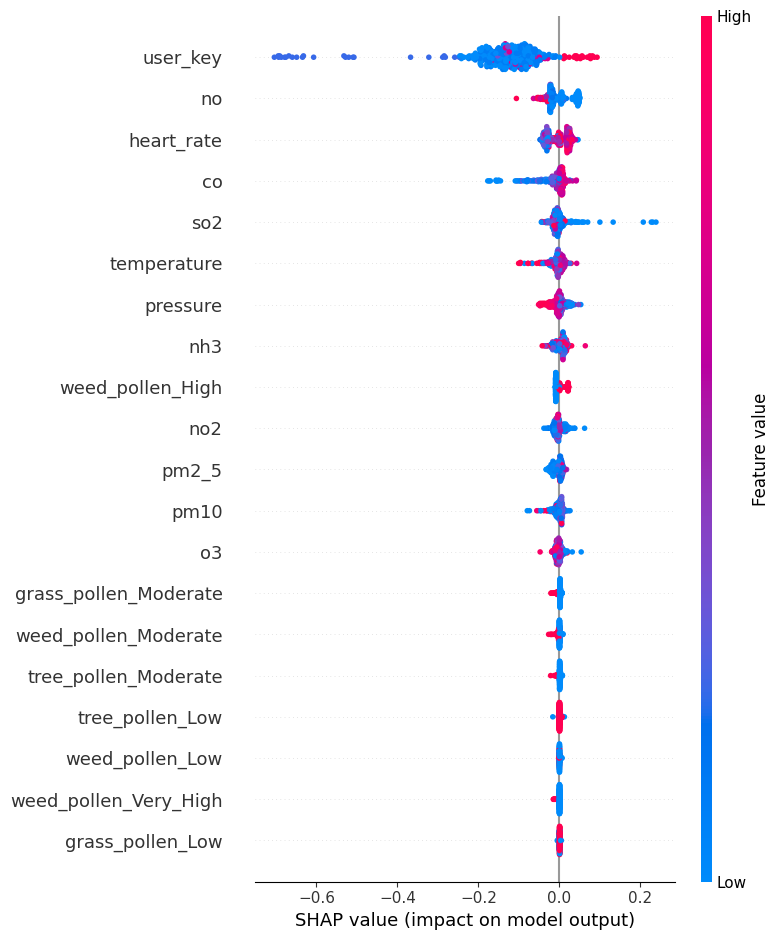

In [64]:
# ============================================================
# SHAP ANALYSIS — BAGGING CLASSIFIER
# ============================================================
import shap

# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------
feature_names = X_train.columns.tolist()

Xtr = (
    X_train.apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(np.float64)
)

Xte = (
    X_test.apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(np.float64)
)

print(f"Train shape: {Xtr.shape}")
print(f"Test shape:  {Xte.shape}")


# ---------------------------------------------------------
# Sample background and explanation data
# ---------------------------------------------------------
background = Xtr.sample(
    len(Xtr),
    random_state=151
)

explain_set = Xte.sample(
    len(Xte),
    random_state=151
)

print(f"Background samples: {len(background)}")
print(f"Explanation samples: {len(explain_set)}")


# ---------------------------------------------------------
# SHAP prediction function
# ---------------------------------------------------------
def predict_positive_class(data):
    data = pd.DataFrame(data, columns=feature_names)
    # return joblib.load("bagging_model_patient_wise_general.joblib").predict_proba(data)[:, 1]
    return joblib.load("bagging_model_PERSONALIZED_UNSEEN.joblib").predict_proba(data)[:, 1]
    # return joblib.load("bagging_model_unseen.joblib").predict_proba(data)[:, 1]


# ---------------------------------------------------------
# Create SHAP explainer
# ---------------------------------------------------------
masker = shap.maskers.Independent(background.values)

explainer = shap.PermutationExplainer(
    predict_positive_class,
    masker
)

max_evals = max(2 * len(feature_names) + 1, 100)

print(f"Running SHAP (max_evals={max_evals})...")

shap_values = explainer(
    explain_set.values,
    max_evals=max_evals
)

print("SHAP analysis completed.")


# =========================================================
# GLOBAL FEATURE IMPORTANCE
# =========================================================

# Mean absolute SHAP:
# Overall magnitude of each feature's influence.
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Mean SHAP:
# Average direction of each feature's influence.
mean_shap = shap_values.values.mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
        "mean_shap": mean_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Save results
shap_importance.to_csv(
    "bagging_shap_importance.csv",
    index=False
)

print("\nTop 20 SHAP Features:")
display(shap_importance.head(20).round(6))


# =========================================================
# BEESWARM PLOT
# =========================================================
# Shows feature importance, direction, and feature-value
# relationships across the explanation dataset.

shap.summary_plot(
    shap_values.values,
    features=explain_set,
    feature_names=feature_names,
    max_display=min(20, len(feature_names)),
    show=True
)

In [65]:
shap_values = explainer(
    explain_set,
    max_evals=max_evals
)

PermutationExplainer explainer: 363it [00:50,  5.42it/s]                         


In [66]:
shap_values_bg = explainer(
    background,
    max_evals=max_evals
)

PermutationExplainer explainer: 844it [01:38,  7.66it/s]


Model: bagging_model_PERSONALIZED_UNSEEN.joblib
Sample Row Index: 579
True Label (y): 0
Predicted Label (y_hat): 0
Predicted Probability f(x): 0.2000



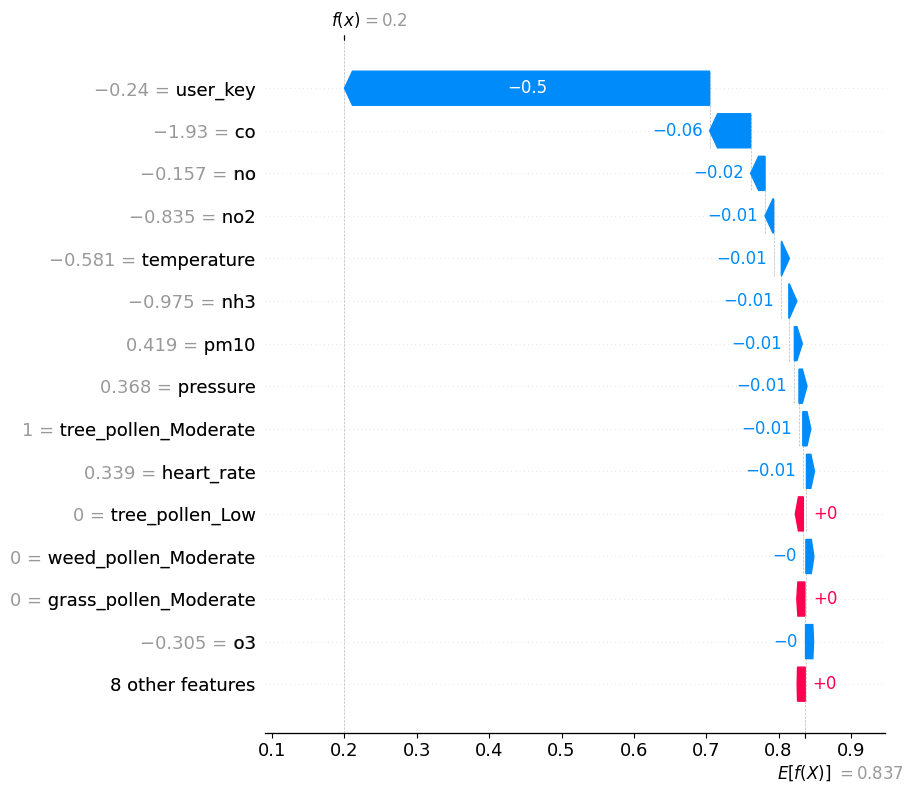

In [67]:
# =========================================================
# WATERFALL PLOT
# =========================================================
# Explains why the model made one specific prediction.


sample_row_idx = 579

if sample_row_idx in explain_set.index:
    selected_set = explain_set
    vals = shap_values
elif sample_row_idx in background.index:
    selected_set = background
    vals = shap_values_bg

sample_index = selected_set.index.get_loc(sample_row_idx)

# model_names = ["bagging_model_patient_wise_general.joblib", "bagging_model_unseen.joblib", "bagging_model_population.joblib"]
model_names = ["bagging_model_PERSONALIZED_UNSEEN.joblib"]

model_name = model_names[0]
model = joblib.load(model_name)

for model_name in model_names:
    model = joblib.load(model_name)

    if model_name == "bagging_model_population.joblib":
        true_label = y.loc[sample_row_idx]
        pred_label = model.predict(selected_set.drop(['user_key'], axis=1).iloc[[sample_index]])[0]
        pred_prob = model.predict_proba(selected_set.drop(['user_key'], axis=1).iloc[[sample_index]])[0, 1]

    else:
        true_label = y.loc[sample_row_idx]
        pred_label = model.predict(selected_set.iloc[[sample_index]])[0]
        pred_prob = model.predict_proba(selected_set.iloc[[sample_index]])[0, 1]

    print(f"Model: {model_name}")
    print(f"Sample Row Index: {sample_row_idx}")
    print(f"True Label (y): {true_label}")
    print(f"Predicted Label (y_hat): {pred_label}")
    print(f"Predicted Probability f(x): {pred_prob:.4f}")
    print()

    shap.plots.waterfall(
        vals[sample_index],
        max_display=15
    )

print("="*50)

In [68]:
selected_set.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

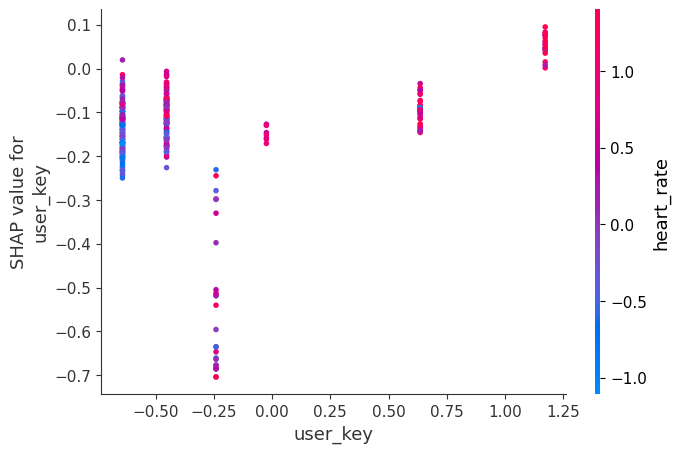

In [69]:
# =========================================================
# DEPENDENCE PLOT
# =========================================================
# Shows how a feature's value affects its SHAP contribution.

FEATURE_TO_ANALYZE = feature_names[0]

shap.dependence_plot(
    FEATURE_TO_ANALYZE,
    shap_values.values,
    explain_set,
    feature_names=feature_names,
    show=True
)

In [70]:
X_train.iloc[0]

,0
user_key,-1.340623
temperature,0.523263
pressure,-0.010119
co,-1.494088
no,-0.130733
no2,0.052463
o3,-0.150994
so2,0.265605
pm2_5,0.417497
pm10,0.268178


In [71]:
X_train.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [72]:
X_test.columns

Index(['user_key', 'temperature', 'pressure', 'co', 'no', 'no2', 'o3', 'so2',
       'pm2_5', 'pm10', 'nh3', 'heart_rate', 'grass_pollen_High',
       'grass_pollen_Low', 'grass_pollen_Moderate', 'tree_pollen_High',
       'tree_pollen_Low', 'tree_pollen_Moderate', 'weed_pollen_High',
       'weed_pollen_Low', 'weed_pollen_Moderate', 'weed_pollen_Very_High'],
      dtype='object')

In [73]:
# save model after training
import joblib
joblib.dump(bag, "bagging_model_patient_wise_general.joblib")   # or "bagging_model.pkl"

['bagging_model_patient_wise_general.joblib']

In [75]:
import time
import joblib
import numpy as np
import os

model_path = "bagging_model_patient_wise_general.joblib"

start = time.perf_counter()
loaded_model = joblib.load(model_path)
load_time = time.perf_counter() - start

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

def benchmark_prediction(model, X_input, n_runs=1000, use_proba=True):
    times = []

    # Warm-up
    for _ in range(10):
        if use_proba:
            model.predict_proba(X_input)
        else:
            model.predict(X_input)

    for _ in range(n_runs):
        start = time.perf_counter()
        if use_proba:
            model.predict_proba(X_input)
        else:
            model.predict(X_input)
        times.append(time.perf_counter() - start)

    times = np.array(times)

    return {
        "samples": len(X_input),
        "mean_ms": times.mean() * 1000,
        "p50_ms": np.percentile(times, 50) * 1000,
        "p95_ms": np.percentile(times, 95) * 1000,
        "p99_ms": np.percentile(times, 99) * 1000,
        "throughput_samples_per_sec": len(X_input) / times.mean()
    }

benchmarks = []

for name, X_batch in {
    "single_sample": X_test.iloc[[0]],
    "batch_10": X_test.iloc[:10],
    "batch_100": X_test.iloc[:100],
    "full_test": X_test
}.items():
    result = benchmark_prediction(loaded_model, X_batch, n_runs=500)
    result["case"] = name
    benchmarks.append(result)

latency_df = pd.DataFrame(benchmarks)

print(f"Model load time: {load_time:.4f} sec")
print(f"Model size: {model_size_mb:.2f} MB")
display(latency_df)

Model load time: 0.0249 sec
Model size: 0.49 MB


,samples,mean_ms,p50_ms,p95_ms,p99_ms,throughput_samples_per_sec,case
0,1,20.649300,15.124021,56.248200,82.277033,48.427792,single_sample
1,10,7.509487,7.227233,9.161543,13.588368,1331.648966,batch_10
2,100,10.198822,8.555449,15.039621,16.805399,9805.054414,batch_100
3,362,9.456728,9.130344,11.461449,16.142394,38279.625377,full_test


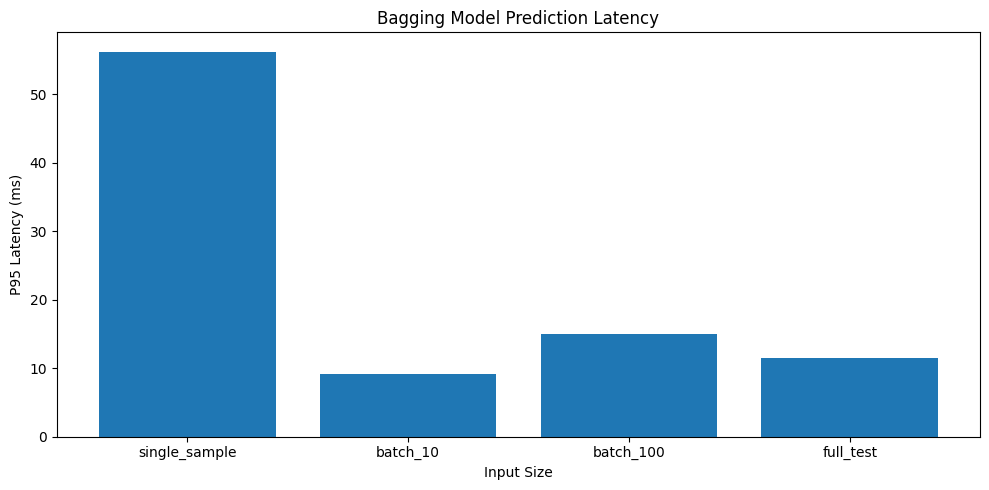

In [76]:
plt.figure(figsize=(10, 5))
plt.bar(latency_df["case"], latency_df["p95_ms"])
plt.ylabel("P95 Latency (ms)")
plt.xlabel("Input Size")
plt.title("Bagging Model Prediction Latency")
plt.tight_layout()
plt.show()

In [77]:
y_bag = bag.predict(X_test)
y_bag

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,

In [78]:
y_bag_prob = bag.predict_proba(X_test)
y_bag_prob = y_bag_prob[:, 1]
y_bag_prob[:10]

array([0.74, 0.86, 0.84, 0.52, 0.64, 0.5 , 0.62, 0.72, 0.62, 0.58])

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Computed metrics for all models across scaling methods:


F1-Score  Precision  Recall   AUPRC
Scaling         Model                                                   
No Scaling      Random Forest          0.9168     0.8700  0.9690  0.9630
                XGBoost                0.9212     0.9150  0.9276  0.9675
                Logistic Regression    0.8704     0.8119  0.9379  0.9223
                Gradient Boosting      0.9170     0.9201  0.9138  0.9557
                Neural Network         0.8870     0.8558  0.9207  0.9460
                Bernoulli NB           0.8479     0.8407  0.8552  0.9096
                Gaussian NB            0.7949     0.8391  0.7552  0.8955
                Bagging                0.9270     0.9130  0.9414  0.9634
Standardization Random Forest          0.9168     0.8700  0.9690  0.9629
                XGBoost                0.9212     0.9150  0.9276  0.9675
                Logistic Regression    0.8690     0.8095  0.9379  0.9218
                Gradient Boosting      0.9135     0.9167  0.9103  0.9550
                Neural Network         0.8805     0.8716  0.8897  0.9436
                Bernoulli NB           0.8479     0.8407  0.8552  0.9099
                Gaussian NB            0.7949     0.8391  0.7552  0.8955
                Bagging                0.9270     0.9130  0.9414  0.9632
Normalization   Random Forest          0.9168     0.8700  0.9690  0.9628
                XGBoost                0.9212     0.9150  0.9276  0.9675
                Logistic Regression    0.8844     0.8086  0.9759  0.9344
                Gradient Boosting      0.9170     0.9201  0.9138  0.9552
                Neural Network         0.8953     0.8399  0.9586  0.9442
                Bernoulli NB           0.8316     0.8288  0.8345  0.8739
                Gaussian NB            0.7949     0.8391  0.7552  0.8955
                Bagging                0.9254     0.9100  0.9414  0.9635

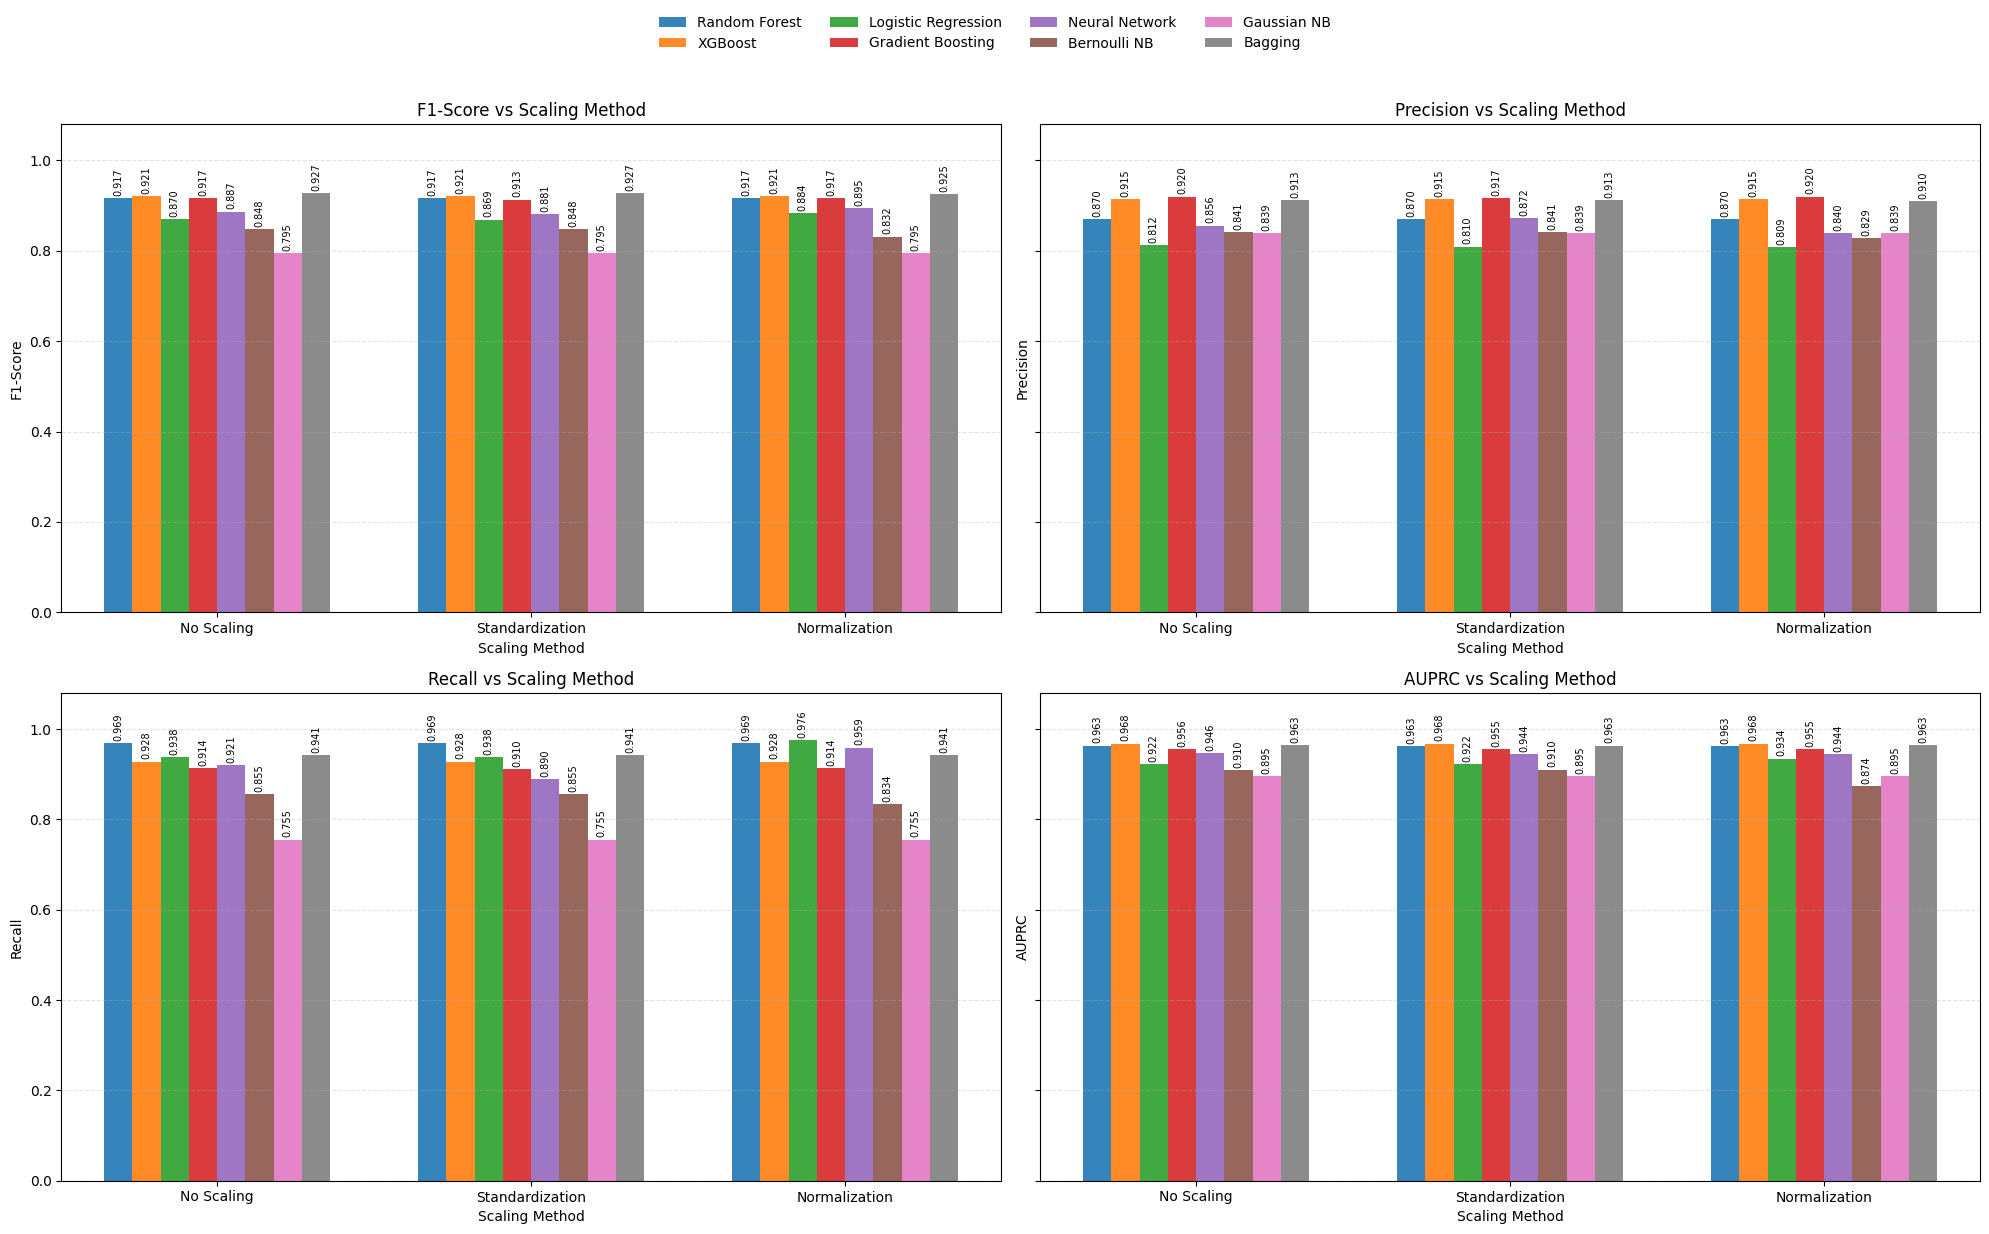

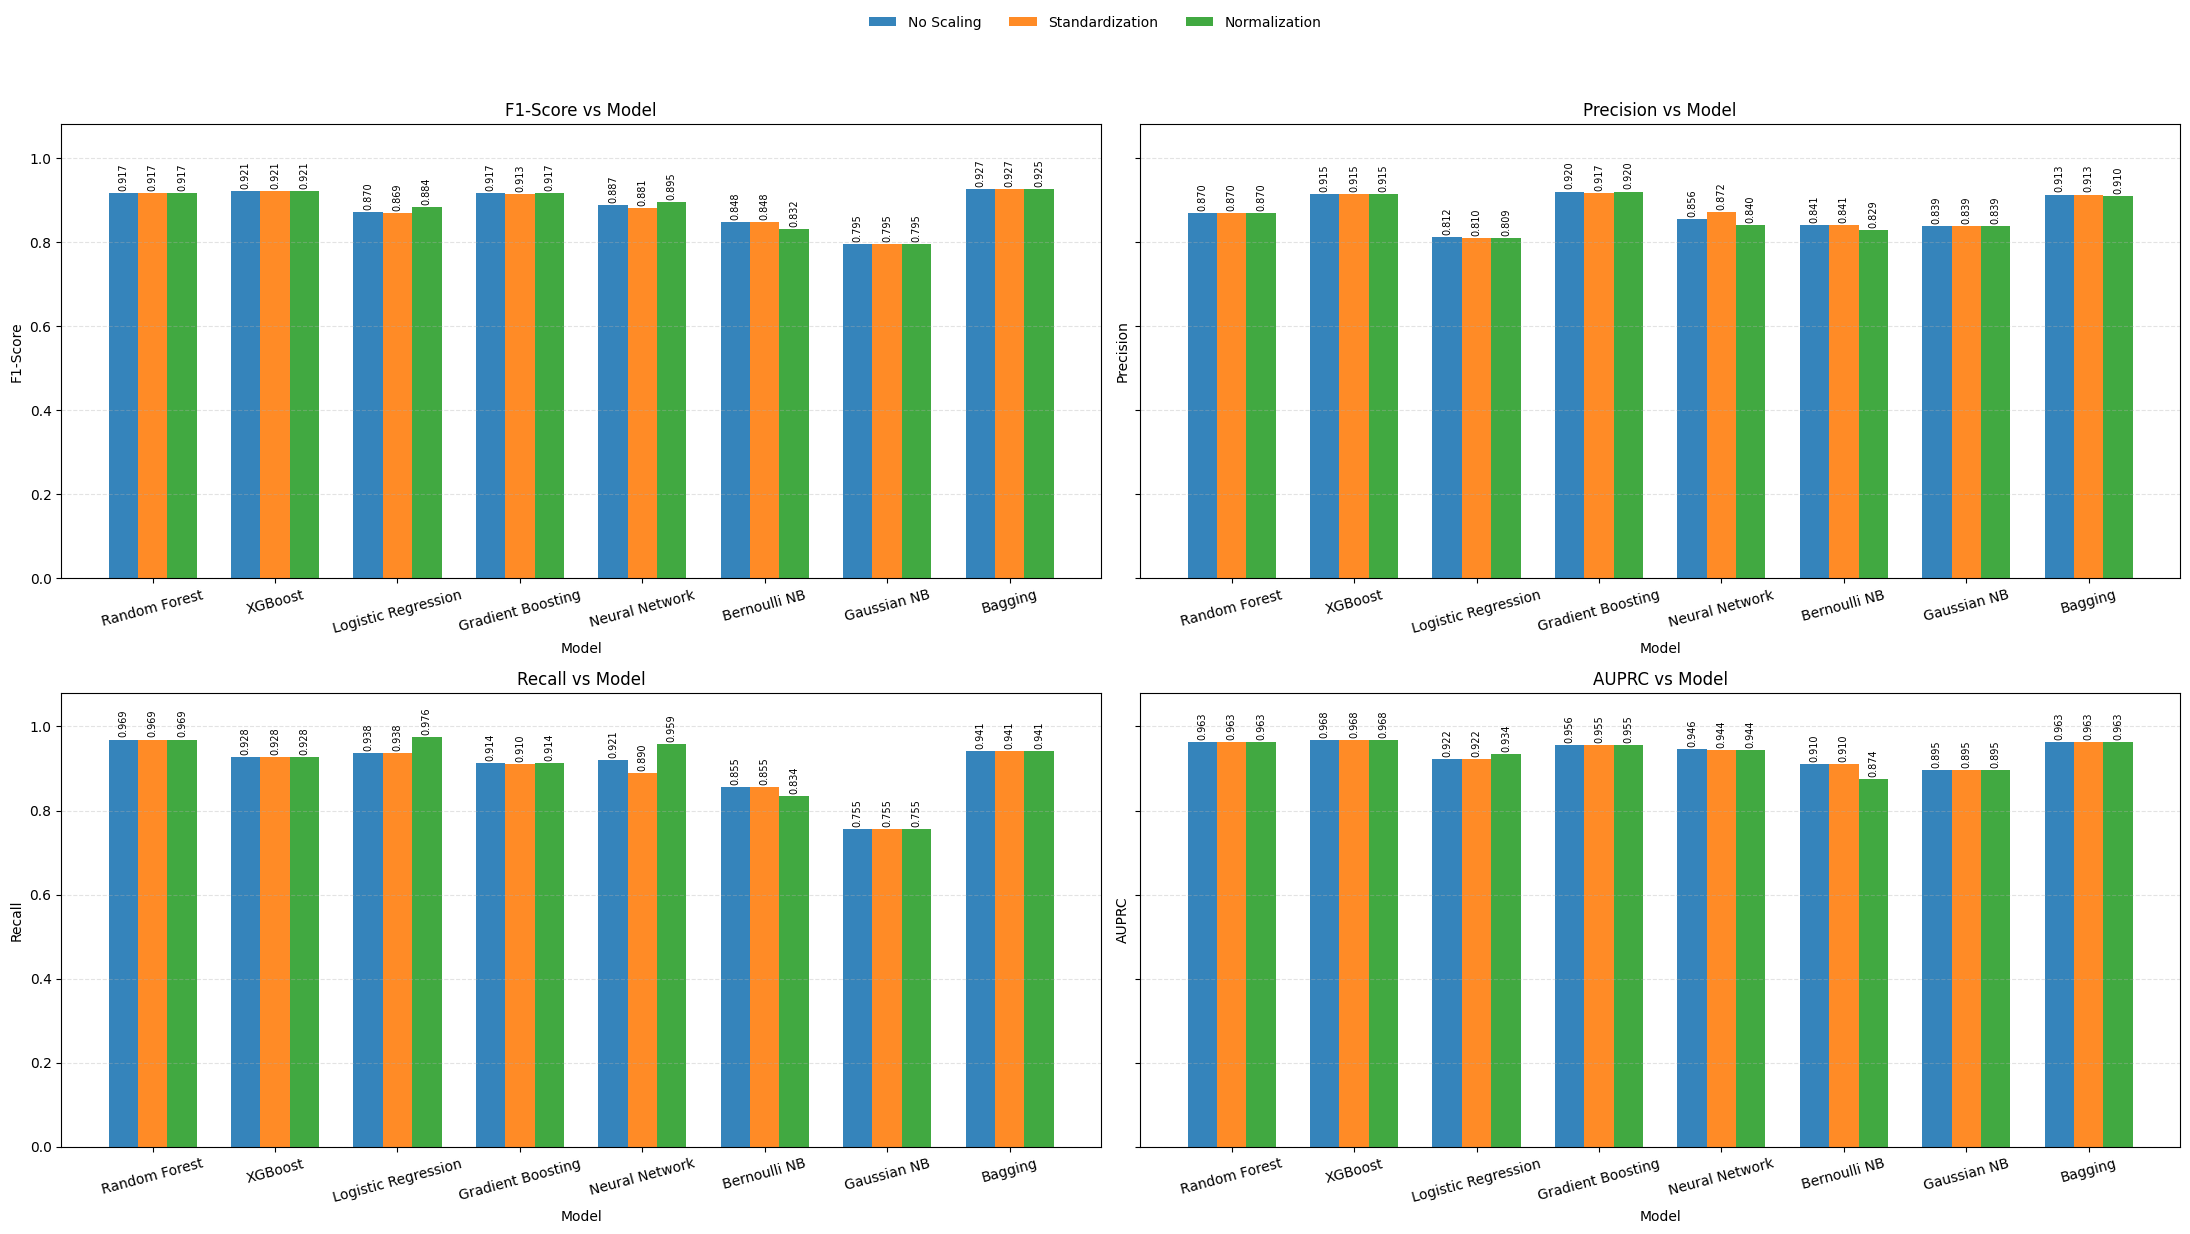

In [79]:
# Compare model performance across scaling methods using computed predictions (not markdown/tabular hardcoding)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

# Use existing feature/target from notebook
X_local = X.copy()
y_local = y.copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_local, y_local, test_size=0.3, stratify=y_local, random_state=151
)

# Use user-specified model settings
xgb_model = XGBClassifier(n_estimators=100, random_state=151, eval_metric='logloss')
bag = BaggingClassifier(random_state=151, n_estimators=50)
dt_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=12, min_samples_split=5, min_samples_leaf=5, random_state=151)
mlp = MLPClassifier(hidden_layer_sizes=(16,18,16), random_state=151, max_iter=150)
gb = GradientBoostingClassifier(n_estimators=50, random_state=151, learning_rate=1.2)
lr = LogisticRegression(random_state=151, max_iter=150, C=0.5)

# Keep RF and NB models as already defined in notebook
model_templates = {
    'Random Forest': rf if 'rf' in globals() else RandomForestClassifier(n_estimators=150, random_state=151),
    'XGBoost': xgb_model,
    'Logistic Regression': lr,
    'Gradient Boosting': gb,
    'Neural Network': mlp,
    'Bernoulli NB': ber_nb if 'ber_nb' in globals() else BernoulliNB(),
    'Gaussian NB': gau_nb if 'gau_nb' in globals() else GaussianNB(),
    'Bagging': bag,
}

# Build scaled splits from the same train/test partition for fair comparison
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

scaling_splits = {
    'No Scaling': (X_train_base.copy(), X_test_base.copy(), y_train_base, y_test_base),
    'Standardization': (
        pd.DataFrame(std_scaler.fit_transform(X_train_base), columns=X_train_base.columns, index=X_train_base.index),
        pd.DataFrame(std_scaler.transform(X_test_base), columns=X_test_base.columns, index=X_test_base.index),
        y_train_base,
        y_test_base,
    ),
    'Normalization': (
        pd.DataFrame(mm_scaler.fit_transform(X_train_base), columns=X_train_base.columns, index=X_train_base.index),
        pd.DataFrame(mm_scaler.transform(X_test_base), columns=X_test_base.columns, index=X_test_base.index),
        y_train_base,
        y_test_base,
    ),
}

# Evaluate all models under each scaling method
rows = []
for scaling_name, (Xtr, Xte, ytr, yte) in scaling_splits.items():
    for model_name, template in model_templates.items():
        model_curr = clone(template)
        model_curr.fit(Xtr, ytr)

        y_pred = model_curr.predict(Xte)

        if hasattr(model_curr, 'predict_proba'):
            y_score = model_curr.predict_proba(Xte)[:, 1]
        elif hasattr(model_curr, 'decision_function'):
            # Convert decision scores to probabilities-like values for AUPRC
            raw = model_curr.decision_function(Xte)
            y_score = 1.0 / (1.0 + np.exp(-raw))
        else:
            y_score = y_pred

        rows.append({
            'Scaling': scaling_name,
            'Model': model_name,
            'F1-Score': f1_score(yte, y_pred, zero_division=0),
            'Precision': precision_score(yte, y_pred, zero_division=0),
            'Recall': recall_score(yte, y_pred, zero_division=0),
            'AUPRC': average_precision_score(yte, y_score),
        })

scaling_metrics_df = pd.DataFrame(rows)

# Keep a fixed ordering across plots
model_order = list(model_templates.keys())
scaling_order = ['No Scaling', 'Standardization', 'Normalization']

print('Computed metrics for all models across scaling methods:')
display(
    scaling_metrics_df
    .set_index(['Scaling', 'Model'])[['F1-Score', 'Precision', 'Recall', 'AUPRC']]
    .round(4)
)

# Figure 1: metric vs scaling method (all models in each subplot)
metric_list = ['F1-Score', 'Precision', 'Recall', 'AUPRC']
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

x = np.arange(len(scaling_order))
width = 0.09

for ax, metric in zip(axes, metric_list):
    for i, model_name in enumerate(model_order):
        vals = []
        for sc in scaling_order:
            val = scaling_metrics_df.loc[
                (scaling_metrics_df['Scaling'] == sc) & (scaling_metrics_df['Model'] == model_name), metric
            ].values[0]
            vals.append(val)

        offset = (i - (len(model_order) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=model_name, alpha=0.9)

        # Add value labels rotated by 90 degrees
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.005,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                rotation=90,
                fontsize=7,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(scaling_order)
    ax.set_title(f'{metric} vs Scaling Method')
    ax.set_xlabel('Scaling Method')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Figure 2: metric vs model (all scaling methods in each subplot)
fig2, axes2 = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes2 = axes2.flatten()

x_models = np.arange(len(model_order))
width2 = 0.24
colors_scaling = {'No Scaling': '#1f77b4', 'Standardization': '#ff7f0e', 'Normalization': '#2ca02c'}

for ax, metric in zip(axes2, metric_list):
    for j, sc in enumerate(scaling_order):
        vals = []
        for m in model_order:
            val = scaling_metrics_df.loc[
                (scaling_metrics_df['Scaling'] == sc) & (scaling_metrics_df['Model'] == m), metric
            ].values[0]
            vals.append(val)

        offset = (j - 1) * width2
        bars = ax.bar(
            x_models + offset,
            vals,
            width2,
            label=sc,
            alpha=0.9,
            color=colors_scaling[sc],
        )

        # Add value labels rotated by 90 degrees
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.005,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                rotation=90,
                fontsize=7,
            )

    ax.set_xticks(x_models)
    ax.set_xticklabels(model_order, rotation=15)
    ax.set_title(f'{metric} vs Model')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

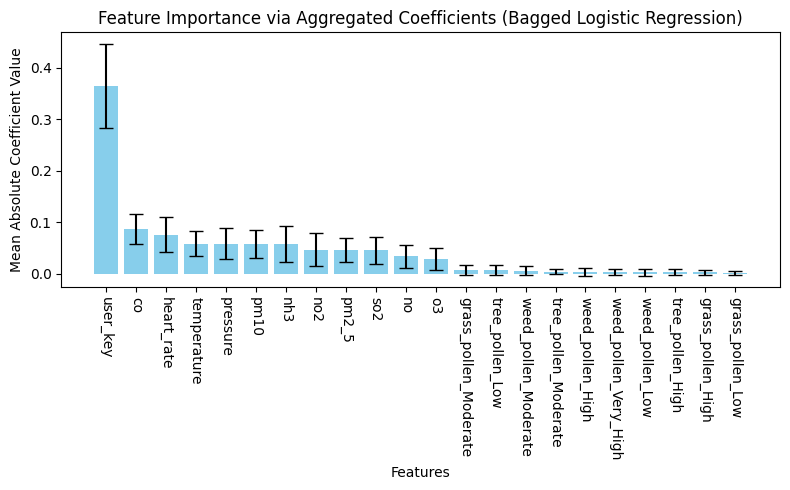

In [80]:
all_coefs = [tree.feature_importances_ for tree in joblib.load("bagging_model_patient_wise_general.joblib").estimators_]

# Calculate the mean and standard deviation across all bootstrapped models
mean_importance = np.mean(all_coefs, axis=0)
std_importance = np.std(all_coefs, axis=0)

# 5. Plot the aggregated coefficients as feature importances
indices = np.argsort(mean_importance)[::-1]
sorted_features = [feature_names[i] for i in indices]

plt.figure(figsize=(8, 5))
plt.title("Feature Importance via Aggregated Coefficients (Bagged Logistic Regression)")
plt.bar(
    range(X.shape[1]),
    mean_importance[indices],
    yerr=std_importance[indices],
    align="center",
    capsize=5,
    color="skyblue",
)
plt.xticks(range(X.shape[1]), sorted_features)
plt.ylabel("Mean Absolute Coefficient Value")
plt.xlabel("Features")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()